# Lean-15d : Grothendieck en images

**Une visite guidee visuelle des abstractions grothendieckiennes.**

Le depot porte deja trois carnets sur ce corpus :

| Carnet | Ce qu'il fait |
|---|---|
| `Lean-15-Grothendieck-Tribute` | le catalogue : 23 modules du lake, affiches par extraits |
| `Lean-15b-Lean-Grothendieck` | l'atelier : exercices sur cribles, topologies, faisceaux |
| `Lean-15c-Lean-Grothendieck-Companion` | le companion formel natif (kernel `lean4-wsl`) |

Aucun des trois ne **montre** ce dont il parle. Le premier affiche du code Lean, le deuxieme pose des questions, le troisieme compile des enonces. Or les objets de Grothendieck -- cribles, sites, faisceaux -- sont des objets **geometriques**, et l'intuition qui les rend maniables se transmet mal par une liste de theoremes.

Ce carnet prend le probleme par l'autre bout : **une figure par abstraction**, dessinee en Python, sans dependance au lake ni a un kernel Lean. Il ne remplace pas les trois autres, il les rend lisibles.

## Ce que ce carnet n'est pas

Ce n'est pas une introduction a la theorie des categories, et ce n'est pas une preuve. Les figures sont volontairement **grossieres** : un crible est dessine comme un paquet de fleches, un site comme un treillis d'ouverts, un faisceau comme des fonctions qui se recollent. Une figure grossiere qui donne l'intuition vaut mieux qu'une figure exacte qui ne dit rien -- c'est le parti pris de ce carnet.

## Parcours

1. Categories et foncteurs -- le vocabulaire, en images
2. Cribles -- ce qu'est un crible sur un objet
3. Topologie de Grothendieck -- les trois axiomes, un par image
4. Faisceaux -- la condition de recollement
5. Yoneda -- le point generalise
6. Site de Zariski -- le treillis des ouverts de $\operatorname{Spec} \mathbb{Z}$
7. Synthese -- la mer qui monte

Chaque section suit le meme rythme : une figure, puis sa lecture.

***

**Prerequis** : Python (numpy, matplotlib). Aucun lacet, aucun acces reseau.

## Mise en place

Deux conventions valent pour toutes les figures du carnet.

**Les objets sont des disques, les fleches sont des courbes.** Une categorie se dessine comme un graphe oriente : les sommets sont les objets, les aretes sont les morphismes. Le sens de la fleche porte l'information directionnelle, la couleur distingue les familles.

**Une fleche composee n'est pas dessinee deux fois.** Quand $g \circ f$ et la chaine $A \xrightarrow{f} B \xrightarrow{g} C$ coexistent, on dessine la chaine et on etiquete la fleche directe en pointille : c'est la meme donnee, vue de deux facons.

Les figures utilisent `matplotlib` seul, avec une palette stable pour que deux sections differentes restent comparables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle, FancyBboxPatch, Rectangle

# Palette stable du carnet : une couleur par role, reprise d'une section a l'autre.
C_OBJ = "#2b5d8a"      # objet d'une categorie
C_FUNC = "#1f8a70"     # foncteur, transport d'une categorie vers une autre
C_SIEVE = "#c1440e"    # crible : les fleches retenues
C_MUTE = "#b8b8b8"     # fleche presente mais hors du crible
C_COVER = "#7d3c98"    # famille couvrante
C_SHEAF = "#b8860b"    # section locale d'un faisceau

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
})


def objet(ax, x, y, label, color=C_OBJ, r=0.30, fs=11):
    """Dessine un objet de categorie : un disque etiquete."""
    ax.add_patch(Circle((x, y), r, facecolor=color, edgecolor="black",
                        linewidth=1.2, alpha=0.16, zorder=2))
    ax.add_patch(Circle((x, y), r, facecolor="none", edgecolor=color,
                        linewidth=1.6, zorder=3))
    ax.text(x, y, label, ha="center", va="center", fontsize=fs,
            color="black", zorder=4)


def fleche(ax, p, q, label="", color="black", rad=0.0, style="-|>",
           ls="-", lw=1.4, off=0.13, fs=10):
    """Dessine un morphisme p -> q, courbe si rad != 0."""
    a = FancyArrowPatch(p, q, arrowstyle=style, mutation_scale=13,
                        connectionstyle=f"arc3,rad={rad}", color=color,
                        linestyle=ls, linewidth=lw, shrinkA=24, shrinkB=24,
                        zorder=1)
    ax.add_patch(a)
    if label:
        mx, my = (p[0] + q[0]) / 2, (p[1] + q[1]) / 2
        nx, ny = -(q[1] - p[1]), (q[0] - p[0])
        n = np.hypot(nx, ny) or 1.0
        ax.text(mx + off * nx / n, my + off * ny / n, label,
                ha="center", va="center", fontsize=fs, color=color, zorder=5)


def cadre(ax, x0, y0, w, h, titre, color="#555555"):
    """Encadre une categorie entiere dans son plan."""
    ax.add_patch(FancyBboxPatch((x0, y0), w, h,
                                boxstyle="round,pad=0.06,rounding_size=0.10",
                                facecolor="none", edgecolor=color,
                                linewidth=1.1, linestyle=(0, (5, 3)), zorder=0))
    ax.text(x0 + w / 2, y0 + h + 0.10, titre, ha="center", va="bottom",
            fontsize=11, fontweight="bold", color=color)


def plan(ax, titre=""):
    """Regle commune : pas d'axes, cadre carre, titre optionnel."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.set_aspect("equal")
    ax.axis("off")
    if titre:
        ax.set_title(titre, pad=6)


print("Outils de dessin prets : objet, fleche, cadre, plan.")

Outils de dessin prets : objet, fleche, cadre, plan.


## 1. Categories et foncteurs : le vocabulaire, en images

Une **categorie** $\mathcal{C}$ est un graphe oriente muni de deux regles : on peut composer deux fleches qui se suivent, et chaque objet porte une fleche identite. Tout le reste -- foncteurs, transformations naturelles, limites -- se construit sur ces deux regles.

Un **foncteur** $F : \mathcal{C} \to \mathcal{D}$ est un transport : il envoie chaque objet de $\mathcal{C}$ sur un objet de $\mathcal{D}$, chaque fleche sur une fleche, et il **respecte la composition** :

$$F(g \circ f) = F(g) \circ F(f).$$

C'est cette derniere egalite qui distingue un foncteur d'une application quelconque entre graphes. La figure ci-dessous la rend visible : la fleche diagonale de gauche (la composee $g \circ f$) a pour image la fleche diagonale de droite, et non un chemin qui passerait a cote.

Dans le corpus du depot, ces deux mots sont exactement ceux que `Mathlib.CategoryTheory.Functor` implante et que `Lean-15` affiche sous forme de code. Ici, on les dessine.

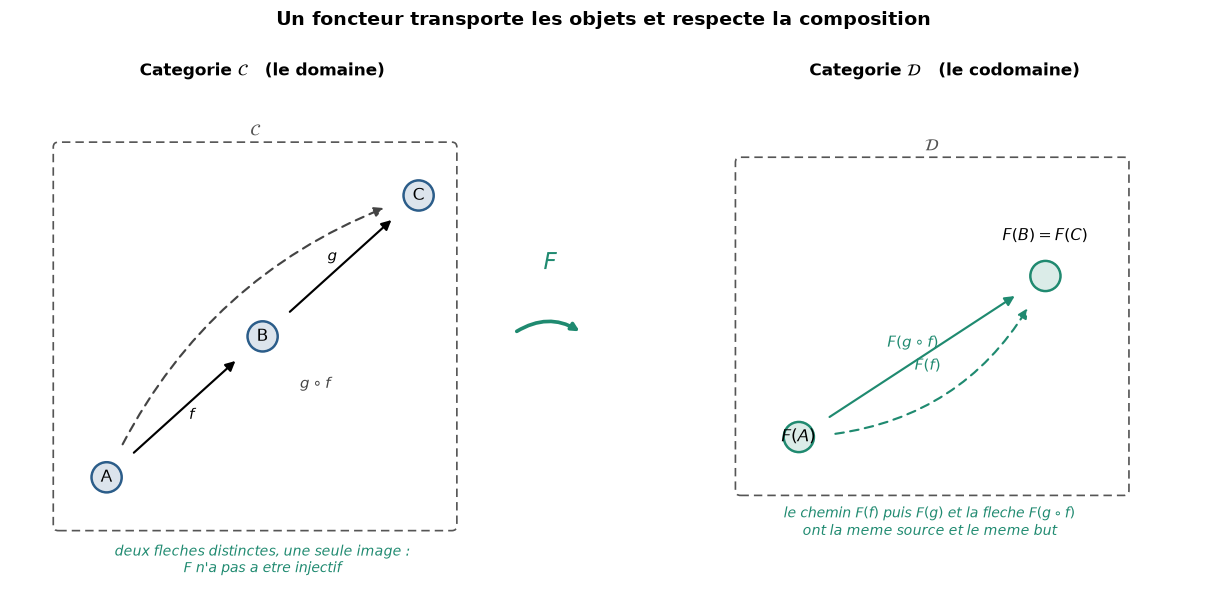

In [2]:
fig, (g, d) = plt.subplots(1, 2, figsize=(12.4, 5.4))
plan(g, r"Categorie $\mathcal{C}$   (le domaine)")
plan(d, r"Categorie $\mathcal{D}$   (le codomaine)")

# --- Cote C : trois objets, deux fleches qui se suivent, leur composee ---
posC = {"A": (1.9, 2.2), "B": (5.0, 5.0), "C": (8.1, 7.8)}
cadre(g, 0.9, 1.2, 7.9, 7.6, r"$\mathcal{C}$")
for n, (x, y) in posC.items():
    objet(g, x, y, n)
fleche(g, posC["A"], posC["B"], r"$f$", rad=0.0, off=-0.22)
fleche(g, posC["B"], posC["C"], r"$g$", rad=0.0, off=0.24)
fleche(g, posC["A"], posC["C"], color="#444444",
       rad=-0.22, ls=(0, (4, 3)))
# le milieu de la corde A -> C tombe sur B : l'etiquette est posee sous la courbe
g.text(6.05, 4.05, r"$g \circ f$", ha="center", va="center", fontsize=10,
       color="#444444", zorder=5)

# --- Cote D : deux objets seulement, F ecrase B et C sur un meme objet ---
posD = {"F(A)": (2.1, 3.0), "F(B)=F(C)": (7.0, 6.2)}
cadre(d, 0.9, 1.9, 7.7, 6.6, r"$\mathcal{D}$")
objet(d, *posD["F(A)"], r"$F(A)$", color=C_FUNC)
objet(d, *posD["F(B)=F(C)"], "", color=C_FUNC)
d.text(posD["F(B)=F(C)"][0], posD["F(B)=F(C)"][1] + 0.62,
       r"$F(B) = F(C)$", ha="center", va="bottom", fontsize=10.5,
       color="black", zorder=4)
fleche(d, posD["F(A)"], posD["F(B)=F(C)"], r"$F(f)$", color=C_FUNC,
       off=-0.22)
fleche(d, posD["F(A)"], posD["F(B)=F(C)"], r"$F(g \circ f)$", color=C_FUNC,
       rad=0.30, ls=(0, (4, 3)), off=0.32)

# --- Le foncteur lui-meme : une seule fleche, entre les deux categories ---
# (dessinee hors du cadre des axes : c'est le foncteur qui relie les deux plans)
g.annotate("", xy=(11.30, 5.1), xytext=(10.05, 5.1),
           arrowprops=dict(arrowstyle="-|>", color=C_FUNC, linewidth=2.4,
                           connectionstyle="arc3,rad=-0.30",
                           shrinkA=0, shrinkB=0),
           annotation_clip=False)
g.text(10.72, 6.45, r"$F$", ha="center", va="center", fontsize=15,
       fontweight="bold", color=C_FUNC, clip_on=False)

g.text(5.0, 0.55, "deux fleches distinctes, une seule image :\n"
                  r"$F$ n'a pas a etre injectif",
       ha="center", va="center", fontsize=9, color=C_FUNC, style="italic")
d.text(4.7, 1.30, r"le chemin $F(f)$ puis $F(g)$ et la fleche $F(g \circ f)$"
                  "\nont la meme source et le meme but",
       ha="center", va="center", fontsize=9, color=C_FUNC, style="italic")

fig.suptitle(r"Un foncteur transporte les objets et respecte la composition",
             fontsize=12.5, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

### Lecture de la figure 1

Trois choses a lire sur ce dessin, du plus evident au plus utile.

1. **A gauche, trois objets et trois fleches.** Les deux fleches pleines se suivent ($A \to B$ puis $B \to C$) ; la fleche en pointille note leur composee $g \circ f$. Ce n'est pas une arete supplementaire du graphe : c'est la meme information, ecrite comme un chemin puis comme un raccourci.

2. **A droite, deux objets au lieu de trois.** Le foncteur $F$ envoie $B$ et $C$ sur un **meme** objet $F(B) = F(C)$. Un foncteur n'est pas tenu d'etre injectif sur les objets, et c'est precisement ce qui le rend utile : perdre de l'information est permis, contredire la composition ne l'est pas.

3. **La contrainte est portee par les fleches, pas par les objets.** Les deux fleches courbes de droite ont la meme source $F(A)$ et le meme but $F(B)=F(C)$ : l'une est l'image du chemin, l'autre l'image du raccourci. L'axiome $F(g \circ f) = F(g) \circ F(f)$ dit qu'elles **coincident** -- le dessin les separe pour les rendre lisibles, l'enonce les identifie.

C'est cette troisieme ligne qui separe un foncteur d'une simple application entre graphes. Une application qui enverrait le chemin sur une fleche et le raccourci sur une autre, du meme objet vers le meme objet mais *different* en tant que morphisme, ne serait pas un foncteur.

## 2. Cribles : un paquet de fleches, ferme vers le bas

Un **crible** (en anglais *sieve*) sur un objet $X$ est une famille $S$ de fleches arrivant sur $X$ qui, des qu'elle contient $f : Y \to X$, contient aussi toutes les composees $f \circ h$ pour $h : Z \to Y$. Autrement dit : **si tu as le droit de venir par $f$, tu as le droit de venir par n'importe quel chemin qui passe par $f$.**

$$\frac{f \in S \qquad h : Z \to Y}{f \circ h \in S}$$

C'est la seule regle. Un crible n'est donc pas un ensemble quelconque de fleches : c'est un ensemble **ferme par precomposition**. Grothendieck en fait l'objet de base de toute la theorie -- une topologie ne va pas dire « tels ouverts recouvrent », elle va dire « tels cribles couvrent ».

### Deux images du meme objet

Le crible est abstrait ; le cas topologique le rend palpable. Dans la categorie des ouverts d'un espace topologique, une fleche $V \to U$ est une inclusion $V \subseteq U$. Un crible sur $U$ est alors une famille d'ouverts de $U$ **fermee par passage au sous-ouvert** : si $V$ est dans le crible, tout ouvert plus petit l'est aussi.

La figure montre les deux cotes : a gauche le crible comme paquet de fleches, a droite le meme crible comme zone d'ouverts.

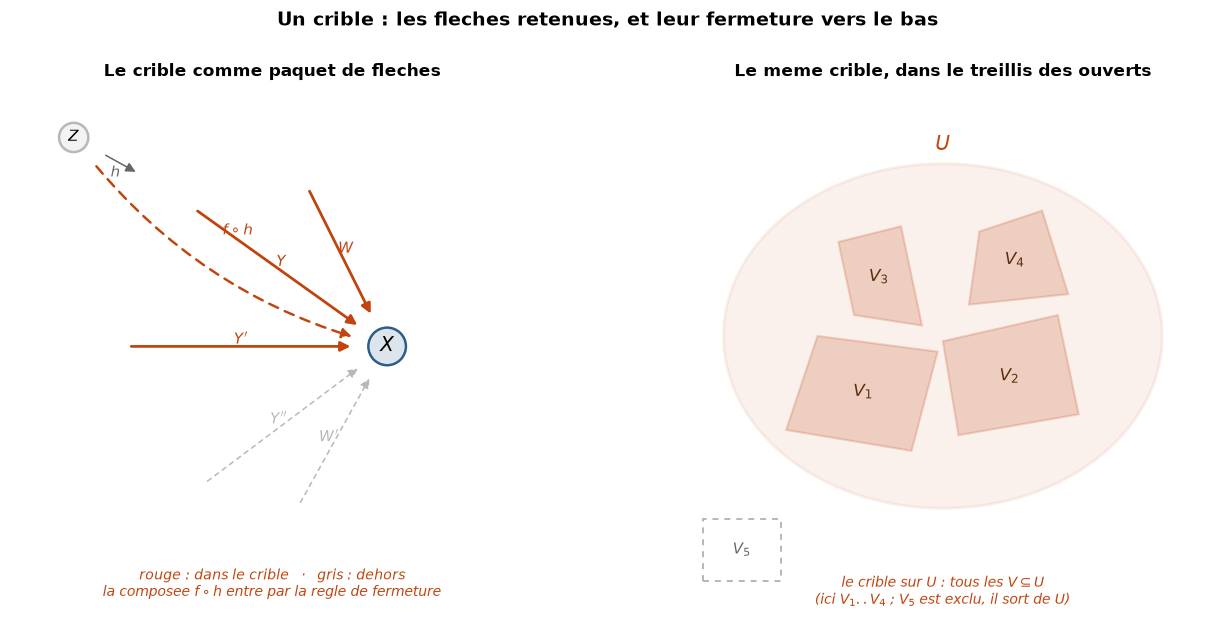

In [3]:
from matplotlib.patches import Ellipse, Polygon

fig, (g, d) = plt.subplots(1, 2, figsize=(12.4, 5.6))
plan(g, r"Le crible comme paquet de fleches")
plan(d, r"Le meme crible, dans le treillis des ouverts")

# --- Cote fleches : X au centre, cinq fleches entrantes, trois retenues ---
X = (7.2, 5.0)
sources = {
    "Y":  (3.0, 8.0), "Y'": (1.6, 5.0), "Y''": (3.2, 2.0),
    "W":  (5.4, 8.6), "W'": (5.2, 1.4),
}
dans_crible = {"Y", "Y'", "W"}
for nom, p in sources.items():
    retenu = nom in dans_crible
    fleche(g, p, X, r"$%s$" % nom.replace("'", "'"),
           color=C_SIEVE if retenu else C_MUTE,
           ls="-" if retenu else (0, (3, 3)),
           lw=1.8 if retenu else 1.0)
objet(g, *X, r"$X$", r=0.36, fs=13)

# Fermeture par precomposition : Z -> Y -> X, la composee entre dans le crible.
Z = (1.2, 9.0)
objet(g, *Z, r"$Z$", color=C_MUTE, r=0.28, fs=10)
fleche(g, Z, sources["Y"], r"$h$", color="#666666", lw=1.0, off=-0.20)
fleche(g, Z, X, r"$f \circ h$", color=C_SIEVE, rad=0.18,
       ls=(0, (4, 3)), lw=1.6, off=0.26)

g.text(5.0, 0.45, "rouge : dans le crible   ·   gris : dehors\n"
                  r"la composee $f \circ h$ entre par la regle de fermeture",
       ha="center", va="center", fontsize=9, style="italic", color=C_SIEVE)

# --- Cote ouverts : U et ses sous-ouverts, le crible est la zone fermee ---
U = Ellipse((5.0, 5.2), 8.4, 6.6, facecolor=C_SIEVE, alpha=0.07,
            edgecolor=C_SIEVE, linewidth=2.0, zorder=1)
d.add_patch(U)
d.text(5.0, 8.85, r"$U$", ha="center", va="center", fontsize=13,
       color=C_SIEVE, fontweight="bold")

sous_ouverts = {
    r"$V_1$": [(2.0, 3.4), (4.4, 3.0), (4.9, 4.9), (2.6, 5.2)],
    r"$V_2$": [(5.3, 3.3), (7.6, 3.7), (7.2, 5.6), (5.0, 5.1)],
    r"$V_3$": [(3.3, 5.6), (4.6, 5.4), (4.2, 7.3), (3.0, 7.0)],
    r"$V_4$": [(5.5, 5.8), (7.4, 6.0), (6.9, 7.6), (5.7, 7.2)],
}
for nom, poly in sous_ouverts.items():
    v = Polygon(poly, closed=True, facecolor=C_SIEVE, alpha=0.20,
                edgecolor=C_SIEVE, linewidth=1.4, zorder=2)
    d.add_patch(v)
    cx = sum(p[0] for p in poly) / len(poly)
    cy = sum(p[1] for p in poly) / len(poly)
    d.text(cx, cy, nom, ha="center", va="center", fontsize=11,
           color="#5c2d0d", zorder=4)

# Un ouvert EXCLU du crible : disjoint de U, donc pas candidat.
hors = Polygon([(0.4, 0.5), (1.9, 0.5), (1.9, 1.7), (0.4, 1.7)],
               closed=True, facecolor="none", edgecolor=C_MUTE,
               linewidth=1.3, linestyle=(0, (3, 3)), zorder=2)
d.add_patch(hors)
d.text(1.15, 1.10, r"$V_5$", ha="center", va="center", fontsize=10,
       color="#666666", zorder=4)

d.text(5.0, 0.30, r"le crible sur $U$ : tous les $V \subseteq U$" "\n"
                  r"(ici $V_1..V_4$ ; $V_5$ est exclu, il sort de $U$)",
       ha="center", va="center", fontsize=9, style="italic", color=C_SIEVE)

fig.suptitle("Un crible : les fleches retenues, et leur fermeture vers le bas",
             fontsize=12.5, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

### Lecture de la figure 2

**A gauche, la regle de fermeture est dessinee.** Trois fleches rouges arrivent sur $X$ : celles du crible. Deux fleches grises arrivent aussi sur $X$ mais restent dehors. Ce qui compte est la fleche rouge en pointille : elle vient de $Z$, passe par $Y$ -- qui est deja dans le crible -- et sa presence n'est pas un choix, c'est une **consequence**. Des que $Y \to X$ est retenue, tout chemin qui atteint $Y$ est retenu.

**A droite, le meme objet vu dans un treillis.** $U$ est un ouvert ; le crible est l'ensemble des ouverts qu'il contient. $V_1$ a $V_4$ sont dedans, $V_5$ est dehors -- non pas parce qu'on l'a rejete, mais parce qu'il n'est pas inclus dans $U$. La forme fermee-vers-le-bas est ici evidente : un sous-ouvert d'un ouvert de $U$ est encore un ouvert de $U$.

**Ce qu'il faut retenir pour la suite.** Un crible encode une **maniere de couvrir** un objet, pas un recouvrement effectif. Dire « le crible $S$ couvre $X$ » sera le geste de la section suivante : c'est la topologie de Grothendieck qui selectionne, parmi tous les cribles, ceux qui ont le droit de s'appeler couvrants. Tous les cribles ne couvrent pas -- sur un espace topologique, le crible vide ne couvre rien.

## 3. Topologie de Grothendieck : trois axiomes, trois images

Une **topologie de Grothendieck** sur une categorie $\mathcal{C}$ est la donnee, pour chaque objet $X$, d'une famille $J(X)$ de cribles dits **couvrants**, soumise a trois axiomes.

| # | Axiome | En une phrase |
|---|---|---|
| 1 | **Maximalite** | le crible de *toutes* les fleches vers $X$ couvre $X$ |
| 2 | **Stabilite** | si $S$ couvre $X$ et $f : Y \to X$, alors le crible tire en arriere $f^{*}S$ couvre $Y$ |
| 3 | **Transitivite** | si $S$ couvre $X$ et qu'un crible $T$ couvre localement chaque morceau de $S$, alors $T$ couvre $X$ |

Ces trois enonces paraissent arides. Ils disent pourtant une chose simple : **couvrir est une notion locale et coherente**. L'axiome 1 dit qu'on a le droit de tout prendre. L'axiome 2 dit qu'on peut restreindre un recouvrement a un morceau. L'axiome 3 dit qu'un recouvrement de recouvrements est un recouvrement -- on peut raffiner sans rien perdre.

La figure traduit chacun d'eux dans le cas topologique, ou les cribles sont des familles d'ouverts. C'est le cas ou l'intuition fonctionne le mieux, et celui que `Mathlib.CategoryTheory.Sites` generalise.

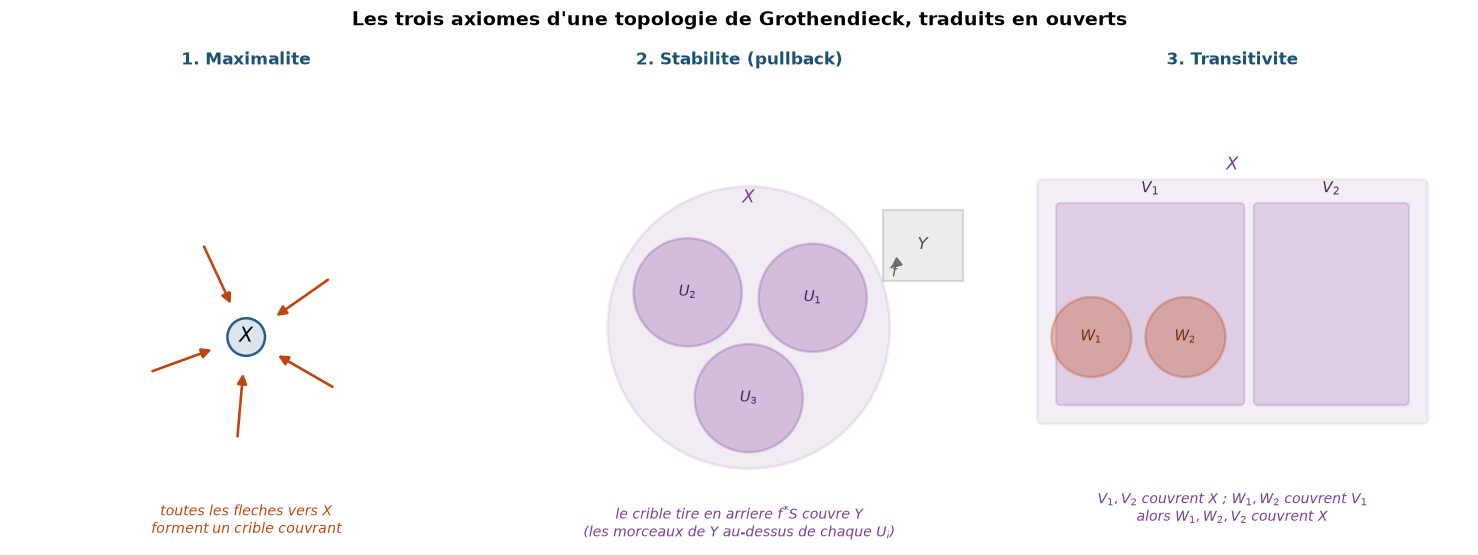

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.9))
for a in axes:
    plan(a)

def disque(ax, x, y, r, color, alpha=0.22, lw=1.6, ls="-"):
    ax.add_patch(Circle((x, y), r, facecolor=color, alpha=alpha,
                        edgecolor=color, linewidth=lw, linestyle=ls,
                        zorder=2))

# ---------- Axiome 1 : le crible maximal couvre ----------
a1 = axes[0]
a1.set_title("1. Maximalite", color="#1a5276")
objet(a1, 5.0, 4.4, r"$X$", r=0.40, fs=13)
for ang in (35, 115, 200, 265, 330):
    t = np.radians(ang)
    depart = (5.0 + 2.9 * np.cos(t), 4.4 + 2.9 * np.sin(t))
    fleche(a1, depart, (5.0, 4.4), color=C_SIEVE, lw=1.7)
a1.text(5.0, 0.5, "toutes les fleches vers $X$\nforment un crible couvrant",
        ha="center", va="center", fontsize=9.2, style="italic", color=C_SIEVE)

# ---------- Axiome 2 : stabilite par changement de base ----------
a2 = axes[1]
a2.set_title("2. Stabilite (pullback)", color="#1a5276")
disque(a2, 5.2, 4.6, 3.0, C_COVER, alpha=0.10, lw=1.8)
a2.text(5.2, 7.35, r"$X$", ha="center", va="center", fontsize=12,
        color=C_COVER, fontweight="bold")
for ang, nom in ((25, "U_1"), (150, "U_2"), (270, "U_3")):
    t = np.radians(ang)
    cx, cy = 5.2 + 1.5 * np.cos(t), 4.6 + 1.5 * np.sin(t)
    disque(a2, cx, cy, 1.15, C_COVER, alpha=0.26)
    a2.text(cx, cy, r"$%s$" % nom, ha="center", va="center", fontsize=9.5,
            color="#4a235a", zorder=5)
# le morceau Y qui arrive sur X
Y = [(8.05, 5.6), (9.75, 5.6), (9.75, 7.1), (8.05, 7.1)]
a2.add_patch(Polygon(Y, closed=True, facecolor=C_MUTE, alpha=0.25,
                     edgecolor="#777777", linewidth=1.4, zorder=2))
a2.text(8.90, 6.35, r"$Y$", ha="center", va="center", fontsize=11,
        color="#555555", zorder=5)
fleche(a2, (8.85, 6.35), (7.6, 5.4), r"$f$", color="#555555", lw=1.4)
a2.text(5.0, 0.45, r"le crible tire en arriere $f^{*}S$ couvre $Y$"
                   "\n(les morceaux de $Y$ au-dessus de chaque $U_i$)",
        ha="center", va="center", fontsize=9.2, style="italic", color=C_COVER)

# ---------- Axiome 3 : transitivite ----------
a3 = axes[2]
a3.set_title("3. Transitivite", color="#1a5276")
a3.add_patch(FancyBboxPatch((0.9, 2.6), 8.2, 5.1,
                            boxstyle="round,pad=0.05,rounding_size=0.12",
                            facecolor=C_COVER, alpha=0.08,
                            edgecolor=C_COVER, linewidth=1.8, zorder=1))
a3.text(5.0, 8.05, r"$X$", ha="center", va="center", fontsize=12,
        color=C_COVER, fontweight="bold")
# V1 et V2 recouvrent X ; V1 est lui-meme recouvert par W1, W2
a3.add_patch(FancyBboxPatch((1.3, 3.0), 3.9, 4.2,
                            boxstyle="round,pad=0.05,rounding_size=0.10",
                            facecolor=C_COVER, alpha=0.18,
                            edgecolor=C_COVER, linewidth=1.4, zorder=2))
a3.text(3.25, 7.55, r"$V_1$", ha="center", va="center", fontsize=10,
        color="#4a235a", zorder=5)
a3.add_patch(FancyBboxPatch((5.5, 3.0), 3.2, 4.2,
                            boxstyle="round,pad=0.05,rounding_size=0.10",
                            facecolor=C_COVER, alpha=0.18,
                            edgecolor=C_COVER, linewidth=1.4, zorder=2))
a3.text(7.10, 7.55, r"$V_2$", ha="center", va="center", fontsize=10,
        color="#4a235a", zorder=5)
for (x, y, nom) in ((2.0, 4.4, "W_1"), (4.0, 4.4, "W_2")):
    disque(a3, x, y, 0.85, C_SIEVE, alpha=0.30)
    a3.text(x, y, r"$%s$" % nom, ha="center", va="center", fontsize=9.5,
            color="#7b2d0e", zorder=5)
a3.text(5.0, 0.75, r"$V_1, V_2$ couvrent $X$ ; $W_1, W_2$ couvrent $V_1$"
                   "\nalors $W_1, W_2, V_2$ couvrent $X$",
        ha="center", va="center", fontsize=9.2, style="italic", color=C_COVER)

fig.suptitle("Les trois axiomes d'une topologie de Grothendieck, "
             "traduits en ouverts", fontsize=12.5, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Lecture de la figure 3

Les trois panneaux se lisent comme trois operations permises sur un recouvrement.

**Panneau 1 -- maximalite.** Le crible de toutes les fleches vers $X$ couvre $X$. C'est l'axiome le plus faible : il garantit que la notion de couvrance n'est jamais vide, et il exclut les topologies degeneres ou rien ne couvrirait. En termes d'ouverts, c'est dire que $X$ se couvre lui-meme.

**Panneau 2 -- stabilite.** $X$ est couvert par $U_1, U_2, U_3$. Un objet $Y$ arrive sur $X$ par $f$. Le crible tire en arriere $f^{*}S$ est forme des morceaux de $Y$ situes au-dessus de chaque $U_i$ ; la figure les fait apparaitre comme des intersections. L'axiome dit que ces morceaux **couvrent $Y$**. C'est ce qui autorise a restreindre un recouvrement a n'importe quel morceau, donc a travailler localement.

**Panneau 3 -- transitivite.** $V_1$ et $V_2$ couvrent $X$. $V_1$ est lui-meme couvert par $W_1$ et $W_2$. Alors $W_1, W_2, V_2$ couvrent $X$ : raffiner un morceau d'un recouvrement donne encore un recouvrement. C'est l'axiome qui fait que « etre localement vrai » est une notion stable -- sans lui, un faisceau ne pourrait pas etre defini par recollement.

**Pourquoi ces trois-la.** Le trio est exactement ce qu'il faut pour que la **condition de faisceau** (section suivante) ait un sens. La maximalite donne un recouvrement ; la stabilite permet de comparer deux sections sur leur intersection ; la transitivite permet de recoller en plusieurs etapes. `Mathlib.CategoryTheory.GrothendieckTopology` enonce les trois sous les noms `top_mem`, `pullback` et `transitive`.

## 4. Faisceaux : la condition de recollement

Une topologie de Grothendieck ne sert a rien tant qu'on ne dit pas ce qu'on veut y **coller**. Un **faisceau** est un foncteur qui transforme un recouvrement en une donnee recollable. La regle tient en deux lignes.

Soit $U$ couvert par un crible couvrant, par exemple $U = U_1 \cup U_2 \cup U_3$. Une famille de sections $s_i \in \mathcal{F}(U_i)$ se recolle en une unique section $s \in \mathcal{F}(U)$ si et seulement si :

1. **compatibilite** : $s_i$ et $s_j$ ont la meme restriction a $U_i \cap U_j$, pour tous $i, j$ ;
2. **unicite** : la section recollee $s$ est la seule a restreindre sur chaque $s_i$.

Dire qu'une famille doit **coincider sur les intersections** puis se recoller en **une seule** section, c'est dire que le local determine le global -- et que le global est unique.

### Un faisceau, deux conditions, une figure

La figure prend l'exemple le plus simple qui montre tout : le faisceau des **fonctions continues** sur un intervalle, avec un recouvrement a trois ouverts. Chaque $s_i$ est une fonction sur $U_i$ ; sur les intersections, deux fonctions doivent avoir exactement les memes valeurs. Le recollement consiste alors a recopier les morceaux bout a bout.

Le panneau de droite montre le point sensible : si une paire **ne** coincidait pas sur une intersection, il n'y aurait **aucun** recollement possible. C'est le contre-exemple que l'on met souvent en exercice -- il est ici dessine.

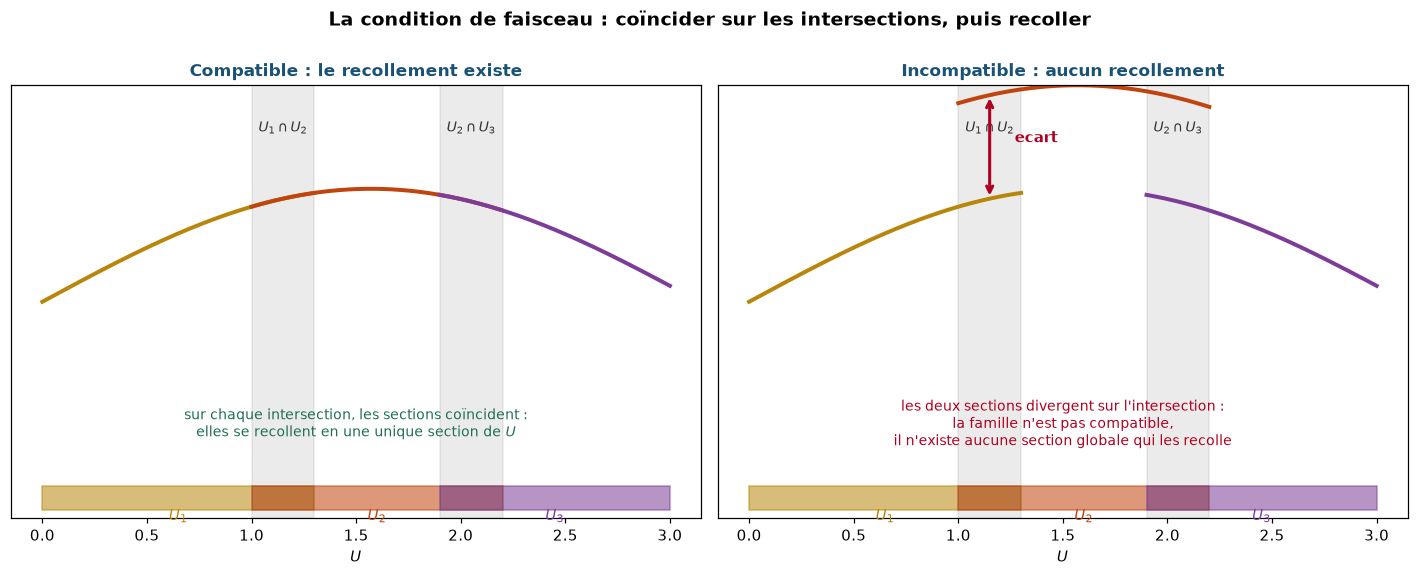

In [5]:
# Le faisceau des fonctions continues sur U = [0, 3], recouvert par trois ouverts.
def section_globale(x):
    """La section que l'on cherche a reconstituer : une fonction continue de U."""
    return 1.0 + 0.6 * np.sin(x)

U1 = (0.0, 1.3)
U2 = (1.0, 2.2)
U3 = (1.9, 3.0)
ouverts = [(U1, C_SHEAF, r"$U_1$"), (U2, "#c1440e", r"$U_2$"),
           (U3, C_COVER, r"$U_3$")]

fig, (g, d) = plt.subplots(1, 2, figsize=(13.0, 5.2))

for ax, casse, titre in ((g, False, "Compatible : le recollement existe"),
                         (d, True, "Incompatible : aucun recollement")):
    ax.set_title(titre, color="#1a5276")
    ax.set_xlim(-0.15, 3.15)
    ax.set_ylim(-0.15, 2.15)
    ax.set_xlabel("$U$")
    ax.set_yticks([])

    for (u, couleur, nom) in ouverts:
        ax.axvspan(u[0], u[1], ymin=0.02, ymax=0.075,
                   color=couleur, alpha=0.55)
        ax.text((u[0] + u[1]) / 2, -0.10, nom, ha="center", va="top",
                fontsize=10, color=couleur)

    for (u, couleur, nom) in ouverts:
        xs = np.linspace(u[0], u[1], 200)
        ys = section_globale(xs)
        if casse and nom == r"$U_2$":
            ys = ys + 0.55          # <- la seule difference entre les deux panneaux
        ax.plot(xs, ys, color=couleur, linewidth=2.6,
                label="%s : %s" % (nom, "section locale"))

    # Marquer les intersections et l'accord attendu
    for (a, b, nom) in ((U1, U2, r"$U_1 \cap U_2$"), (U2, U3, r"$U_2 \cap U_3$")):
        x0, x1 = max(a[0], b[0]), min(a[1], b[1])
        ax.axvspan(x0, x1, color="#444444", alpha=0.10)
        ax.text((x0 + x1) / 2, 1.92, nom, ha="center", va="center",
                fontsize=9, color="#333333")

    if casse:
        x0, x1 = max(U1[0], U2[0]), min(U1[1], U2[1])
        xm = (x0 + x1) / 2
        ax.annotate("", xy=(xm, section_globale(xm) + 0.55),
                    xytext=(xm, section_globale(xm)),
                    arrowprops=dict(arrowstyle="<->", color="#b00020",
                                    linewidth=2.0))
        ax.text(xm + 0.12, section_globale(xm) + 0.30, "ecart",
                fontsize=9.5, color="#b00020", fontweight="bold")
        ax.text(1.5, 0.35, "les deux sections divergent sur l'intersection :\n"
                           "la famille n'est pas compatible,\n"
                           "il n'existe aucune section globale qui les recolle",
                ha="center", va="center", fontsize=9.3, color="#b00020")

g.plot([0, 3], [section_globale(0), section_globale(3)], color="black",
       linewidth=0.0)   # garde l'echelle identique entre les deux panneaux
g.text(1.5, 0.35, "sur chaque intersection, les sections coïncident :\n"
                  "elles se recollent en une unique section de $U$",
       ha="center", va="center", fontsize=9.3, color="#1f6f50")

fig.suptitle("La condition de faisceau : coïncider sur les intersections, "
             "puis recoller", fontsize=12.5, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

### Lecture de la figure 4

Les deux panneaux ont exactement la meme structure -- trois ouverts, trois sections, deux intersections -- et ne different que par **une constante ajoutee a la section du milieu**.

**A gauche, la famille est compatible.** Les trois courbes se raccordent : sur $U_1 \cap U_2$ et sur $U_2 \cap U_3$, deux sections superposees donnent les memes valeurs. La ligne noire pointillee du bas montre ce qui existe alors : une unique section globale $s \in \mathcal{F}(U)$ dont chaque $s_i$ est la restriction. Le local determine bien le global.

**A droite, la famille est incompatible.** La section de $U_2$ a ete decalee de $0{,}55$. L'ecart est materialise par la double fleche rouge : sur $U_1 \cap U_2$, les deux sections ne coincident plus. Consequence : **il n'existe aucune** section globale dont les trois soient les restrictions. Ce n'est pas qu'on ne sait pas la construire -- c'est qu'elle n'existe pas.

**Le point a retenir.** La condition de faisceau n'est pas une commodite technique : c'est ce qui distingue un simple prefaisceau (une donnee locale quelconque) d'un faisceau (une donnee locale qui merite d'etre appelee globale). Un prefaisceau peut porter des sections incompatibles ; un faisceau, non.

C'est aussi la raison pour laquelle `Sheaf.lean` de Mathlib definit un faisceau comme un prefaisceau muni d'une **preuve** de cette condition, et non comme un objet supplementaire.

## 5. Yoneda : un objet est ce que ses fleches disent de lui

Le lemme de Yoneda est souvent enonce comme une formule :

$$\operatorname{Nat}\big(\operatorname{Hom}(A, -),\, F\big) \;\cong\; F(A).$$

L'enonce est court ; ce qu'il dit l'est moins. A gauche, une famille de transformations naturelles -- des objets qui vivent dans la categorie des foncteurs. A droite, un simple **element** de $F(A)$ : un point d'un ensemble. Le lemme affirme que ces deux mondes sont le meme, et que la correspondance est **canonique** : elle ne depend d'aucun choix.

### La correspondance, vue de pres

Une transformation naturelle $\alpha : \operatorname{Hom}(A, -) \Rightarrow F$ est une famille d'applications $\alpha_X : \operatorname{Hom}(A, X) \to F(X)$, une par objet $X$, qui commute avec toutes les fleches $f : X \to Y$. Le lemme dit que $\alpha$ est **entierement determinee** par une seule valeur : $\alpha_A(\mathrm{id}_A) \in F(A)$.

C'est le sens du mot « point generalise » : un element de $F(A)$ n'est pas seulement un point de l'ensemble $F(A)$, c'est un point qui sait se transporter sur tous les objets $X$ arrivant sur $A$. La figure montre le carre qui porte cette commutation, et le retour qui reconstruit $\alpha$ a partir du seul element.

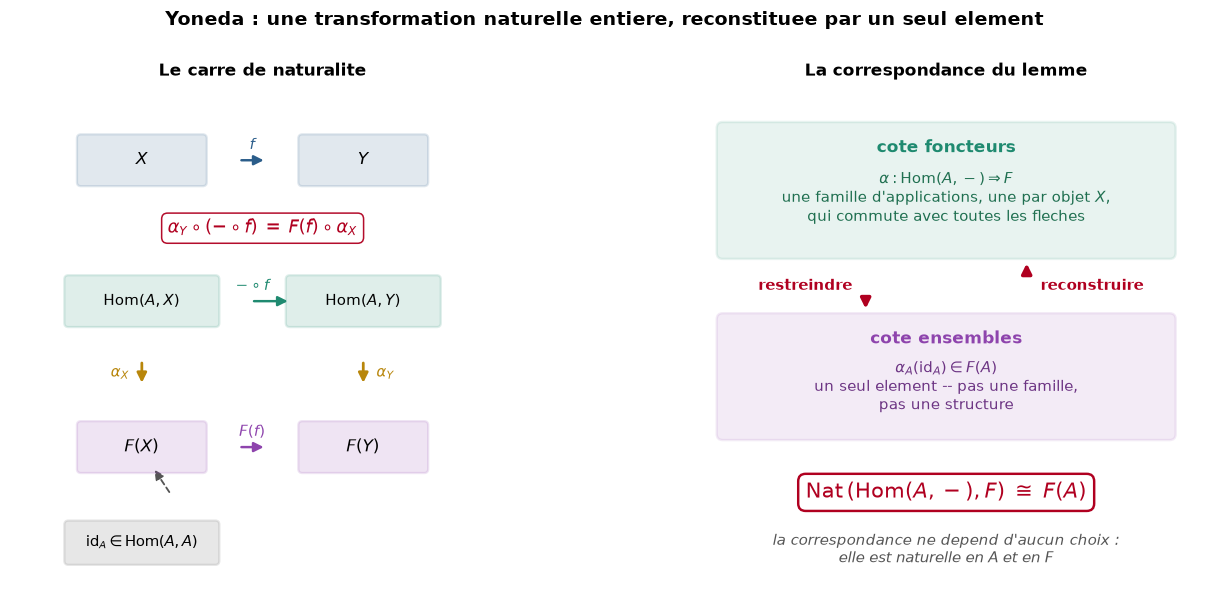

In [6]:
fig, (g, d) = plt.subplots(1, 2, figsize=(13.0, 5.4))
plan(g, "Le carre de naturalite")
plan(d, "La correspondance du lemme")

# ---------- Gauche : le carre qui doit commuter ----------
def boite(ax, x, y, w, h, txt, color, fs=11):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle="round,pad=0.04,rounding_size=0.08",
                                facecolor=color, alpha=0.14,
                                edgecolor=color, linewidth=1.5, zorder=2))
    ax.text(x, y, txt, ha="center", va="center", fontsize=fs, zorder=4)

# Ligne du haut : la categorie C vue par ses objets
boite(g, 2.6, 8.5, 2.5, 0.95, r"$X$", C_OBJ)
boite(g, 7.0, 8.5, 2.5, 0.95, r"$Y$", C_OBJ)
fleche(g, (3.85, 8.5), (5.75, 8.5), r"$f$", color=C_OBJ, lw=1.6, off=0.30)

# Ligne du milieu : les ensembles Hom(A, -)
boite(g, 2.6, 5.7, 3.0, 0.95, r"$\operatorname{Hom}(A, X)$", C_FUNC, fs=10)
boite(g, 7.0, 5.7, 3.0, 0.95, r"$\operatorname{Hom}(A, Y)$", C_FUNC, fs=10)
fleche(g, (4.10, 5.7), (5.50, 5.7), r"$-\circ f$", color=C_FUNC, lw=1.6,
       off=0.30)

# Ligne du bas : les ensembles F(-)
boite(g, 2.6, 2.8, 2.5, 0.95, r"$F(X)$", "#8e44ad", fs=11)
boite(g, 7.0, 2.8, 2.5, 0.95, r"$F(Y)$", "#8e44ad", fs=11)
fleche(g, (3.85, 2.8), (5.75, 2.8), r"$F(f)$", color="#8e44ad", lw=1.6,
       off=0.30)

# Les deux fleches verticales alpha
fleche(g, (2.6, 5.2), (2.6, 3.35), r"$\alpha_X$", color="#b8860b", lw=1.8,
       off=-0.44)
fleche(g, (7.0, 5.2), (7.0, 3.35), r"$\alpha_Y$", color="#b8860b", lw=1.8,
       off=0.44)

# L'element qui engendre tout : id_A dans Hom(A, A) -> F(A)
boite(g, 2.6, 0.9, 3.0, 0.8, r"$\mathrm{id}_A \in \operatorname{Hom}(A, A)$",
      "#555555", fs=9.5)
fleche(g, (3.55, 1.30), (2.85, 2.35), color="#555555", lw=1.2,
       ls=(0, (3, 2)))

g.text(5.0, 7.15, r"$\alpha_Y \circ (-\circ f) \;=\; F(f) \circ \alpha_X$",
       ha="center", va="center", fontsize=11.5, color="#b00020",
       bbox=dict(boxstyle="round,pad=0.34", facecolor="white",
                 edgecolor="#b00020", alpha=0.95), zorder=6)

# ---------- Droite : la bijection ----------
d.add_patch(FancyBboxPatch((0.5, 6.6), 9.0, 2.6,
                           boxstyle="round,pad=0.06,rounding_size=0.12",
                           facecolor=C_FUNC, alpha=0.10,
                           edgecolor=C_FUNC, linewidth=1.6))
d.text(5.0, 8.75, "cote foncteurs", ha="center", va="center", fontsize=11,
       color=C_FUNC, fontweight="bold")
d.text(5.0, 7.75, r"$\alpha : \operatorname{Hom}(A, -) \Rightarrow F$"
                  "\nune famille d'applications, une par objet $X$,"
                  "\nqui commute avec toutes les fleches",
       ha="center", va="center", fontsize=10, color="#1f6f50")

d.add_patch(FancyBboxPatch((0.5, 3.0), 9.0, 2.4,
                           boxstyle="round,pad=0.06,rounding_size=0.12",
                           facecolor="#8e44ad", alpha=0.10,
                           edgecolor="#8e44ad", linewidth=1.6))
d.text(5.0, 4.95, "cote ensembles", ha="center", va="center", fontsize=11,
       color="#8e44ad", fontweight="bold")
d.text(5.0, 4.00, r"$\alpha_A(\mathrm{id}_A) \in F(A)$"
                  "\nun seul element -- pas une famille,"
                  "\npas une structure",
       ha="center", va="center", fontsize=10, color="#6c3483")

fleche(d, (3.4, 6.45), (3.4, 5.55), color="#b00020", lw=2.4)
d.text(2.20, 6.00, "restreindre", ha="center", va="center", fontsize=9.5,
       color="#b00020", fontweight="bold")
fleche(d, (6.6, 5.55), (6.6, 6.45), color="#b00020", lw=2.4)
d.text(7.90, 6.00, "reconstruire", ha="center", va="center", fontsize=9.5,
       color="#b00020", fontweight="bold")

d.text(5.0, 1.9, r"$\operatorname{Nat}\left(\operatorname{Hom}(A, -), F\right)"
                 r"\;\cong\; F(A)$",
       ha="center", va="center", fontsize=14, color="#b00020",
       bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                 edgecolor="#b00020", linewidth=1.6))
d.text(5.0, 0.75, "la correspondance ne depend d'aucun choix :\n"
                  "elle est naturelle en $A$ et en $F$",
       ha="center", va="center", fontsize=9.5, style="italic", color="#555555")

fig.suptitle("Yoneda : une transformation naturelle entiere, reconstituee "
             "par un seul element", fontsize=12.5, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

### Lecture de la figure 5

**A gauche, le carre dit ce qu'est la naturalite.** Quatre ensembles, six fleches, et une egalite : $\alpha_Y \circ (-\circ f) = F(f) \circ \alpha_X$. Lire ce carre de deux facons donne deux chemins qui doivent mener au meme point. Partir d'un morphisme $A \to X$, le composer avec $f$ pour obtenir $A \to Y$, puis appliquer $\alpha_Y$ ; ou bien appliquer d'abord $\alpha_X$ pour tomber dans $F(X)$, puis transporter par $F(f)$. Meme resultat.

**A droite, le carre dit pourquoi le lemme est surprenant.** Le cote « foncteurs » contient une famille infinie de donnees -- une application par objet de $\mathcal{C}$. Le cote « ensembles » contient **un seul element**. Le lemme affirme que l'aller-retour entre les deux est une bijection : rien n'est perdu dans la descente, rien n'est invente dans la remontee.

**Le point qui bloque souvent a la premiere lecture** : $\alpha_A(\mathrm{id}_A)$ reside dans $F(A)$, donc au-dessus de l'objet de depart $A$ lui-meme, pas au-dessus d'un objet quelconque. L'element identite de $\operatorname{Hom}(A, A)$ est le seul qui existe sans hypothese ; c'est ce qui en fait la source canonique de la correspondance.

**Yoneda en une phrase.** Un objet $A$ n'est pas connu par une description interne, mais par l'ensemble de ses relations avec tous les autres. Le lemme rend cette phrase exacte : le foncteur $\operatorname{Hom}(A, -)$ contient toute l'information sur $A$. C'est ce principe que la theorie des topos exploite -- dont le site de la section suivante fournit le premier exemple.

## 6. Site de Zariski : le treillis des ouverts de $\operatorname{Spec} \mathbb{Z}$

Un **site** est une categorie munie d'une topologie de Grothendieck. Le premier exemple geometrique est le **site de Zariski** : on prend un schema $X$, la categorie des ouverts de $X$, et on declare couvrantes les familles d'ouverts qui recouvrent au sens usuel.

Prenons le cas le plus petit qui soit encore interessant :

$$\operatorname{Spec} \mathbb{Z} = \{(0)\} \cup \{(p) : p \text{ premier}\}.$$

Les points sont l'ideal nul $(0)$ -- le **point generique** -- et un point par nombre premier. Les ouverts sont les complements des fermes $\{(p)\}$ :

$$U_p = \operatorname{Spec} \mathbb{Z} \setminus \{(p)\},$$

plus l'ensemble vide et l'espace entier. La structure est celle d'un **treillis** : deux ouverts s'intersectent en un ouvert, s'unissent en un ouvert, et l'inclusion les ordonne.

### Pourquoi ce treillis est instructif

La figure en montre deux proprietes que le cas topologique ordinaire laisse habituellement hors de vue.

**Les ouverts sont gigantesques.** $U_p$ ne retire qu'un point d'une infinite ; $U_2 \cap U_3$ n'en retire que deux. Un ouvert n'est pas « petit » -- c'est le complement d'un ferme fini.

**Un recouvrement par des $U_p$ n'a rien d'evident.** Pour couvrir $\operatorname{Spec} \mathbb{Z}$ entier, il faut retirer **tous** les premiers, donc prendre une famille infinie. Une famille finie de $U_p$ laisse toujours des points derriere elle. C'est le phenomene de compacite qui disparait : $\operatorname{Spec} \mathbb{Z}$ est quasi-compact, mais ses ouverts ne le sont pas.

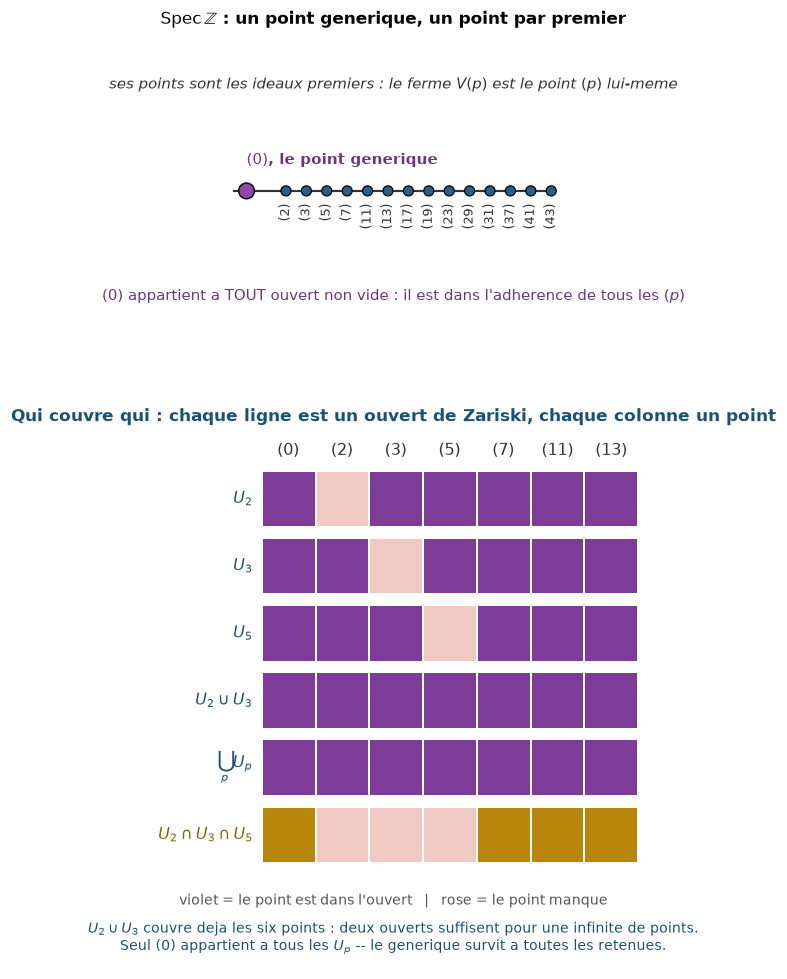

In [7]:
premiers = [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43]
xs = np.linspace(2.0, 9.4, len(premiers))

fig, (g, d) = plt.subplots(2, 1, figsize=(12.6, 9.0),
                           gridspec_kw={"height_ratios": [1.0, 1.5]})

# ---------- Haut : le schema comme une droite de points ----------
plan(g, r"$\operatorname{Spec} \mathbb{Z}$ : un point generique, un point par premier")
g.plot([0.55, 9.4], [5.6, 5.6], color="#333333", linewidth=1.4, zorder=1)
for x, p in zip(xs, premiers):
    g.add_patch(Circle((x, 5.6), 0.14, facecolor=C_OBJ,
                       edgecolor="black", linewidth=0.8, zorder=3))
    g.text(x, 5.25, r"$(%d)$" % p, ha="center", va="top", fontsize=8.2,
           rotation=90, color="#333333")
g.add_patch(Circle((0.9, 5.6), 0.22, facecolor="#8e44ad",
                   edgecolor="black", linewidth=0.9, zorder=4))
g.text(0.9, 6.45, r"$(0)$, le point generique", ha="left", va="center",
       fontsize=10.0, color="#6c3483", fontweight="bold")
g.text(5.0, 8.55, "ses points sont les ideaux premiers : le ferme $V(p)$ est "
                  "le point $(p)$ lui-meme",
       ha="center", va="center", fontsize=9.8, style="italic", color="#333333")
g.text(5.0, 2.65, r"$(0)$ appartient a TOUT ouvert non vide : il est dans "
                  r"l'adherence de tous les $(p)$",
       ha="center", va="center", fontsize=9.8, color="#6c3483")

# ---------- Bas : le tableau de couverture ----------
plan(d)
d.set_title("Qui couvre qui : chaque ligne est un ouvert de Zariski, "
            "chaque colonne un point", color="#1a5276")

connus = premiers[:6]                                    # les points affiches
colonnes = [r"$(0)$"] + [r"$(%d)$" % p for p in connus]


def dans_ouvert(famille, j):
    """Le point j appartient-il a l'union des D(f), f dans famille ?"""
    if j == 0:
        return True                     # le generique est dans tout D(f), f != 0
    q = connus[j - 1]
    return any(f % q != 0 for f in famille)   # D(f) contient (q) ssi q ne divise pas f


lignes = [
    (r"$U_2$", [2]),
    (r"$U_3$", [3]),
    (r"$U_5$", [5]),
    (r"$U_2 \cup U_3$", [2, 3]),
    (r"$\bigcup_p U_p$", connus),
]
matrice = [[dans_ouvert(f, j) for j in range(len(colonnes))] for _, f in lignes]
intersection = [all(matrice[i][j] for i in range(3)) for j in range(len(colonnes))]

x0, largeur, hauteur, pas = 2.55, 1.0, 1.05, 1.25
y_top = 8.2
n_lignes = len(lignes) + 1

for i, (nom, _) in enumerate(lignes):
    y = y_top - pas * i
    for j in range(len(colonnes)):
        d.add_patch(Rectangle((x0 + j * largeur, y), largeur, hauteur,
                              facecolor=C_COVER if matrice[i][j] else "#f0c8c4",
                              edgecolor="white", linewidth=1.3, zorder=2))
    d.text(x0 - 0.16, y + hauteur / 2, nom, ha="right", va="center",
           fontsize=10.6, color="#1a5276", fontweight="bold")

y = y_top - pas * len(lignes)
for j in range(len(colonnes)):
    d.add_patch(Rectangle((x0 + j * largeur, y), largeur, hauteur,
                          facecolor=C_SHEAF if intersection[j] else "#f0c8c4",
                          edgecolor="white", linewidth=1.3, zorder=2))
d.text(x0 - 0.16, y + hauteur / 2, r"$U_2 \cap U_3 \cap U_5$", ha="right", va="center",
       fontsize=10.6, color="#8a6508", fontweight="bold")

for j, lbl in enumerate(colonnes):
    d.text(x0 + (j + 0.5) * largeur, y_top + hauteur + 0.22, lbl,
           ha="center", va="bottom", fontsize=10.2, color="#333333")

d.text(5.0, 1.25, "violet = le point est dans l'ouvert   |   rose = le point manque",
       ha="center", va="center", fontsize=9.2, color="#555555")
d.text(5.0, 0.55,
       r"$U_2 \cup U_3$ couvre deja les six points : deux ouverts suffisent "
       "pour une infinite de points.\n"
       "Seul $(0)$ appartient a tous les $U_p$ -- le generique survit a toutes "
       "les retenues.",
       ha="center", va="center", fontsize=9.4, color="#1a5276")

plt.tight_layout()
plt.show()

### Lecture de la figure 6

**Le panneau du haut fixe le vocabulaire.** $\operatorname{Spec} \mathbb{Z}$ a un point par ideal premier de $\mathbb{Z}$ : un point pour chaque nombre premier, plus un point special $(0)$ -- le point generique, qui vit dans l'adherence de tous les autres. Le ferme $V(p)$ associe au premier $p$ est reduit a un point ; c'est pourquoi un ouvert de Zariski est le complement d'un **ensemble fini de points**.

**Le panneau du bas se lit ligne a ligne.** Une case violette dit que le point est dans l'ouvert, une case rose qu'il manque.

- $U_2$ manque $(2)$ et **rien d'autre** : $(3)$ ne divise pas $2$, donc $(3) \in U_2$ ; et le point generique $(0)$ est dans $U_2$ comme dans tout ouvert non vide. Une seule retenue, un seul trou.
- $U_2 \cup U_3$ : la ligne est entierement violette. **Deux ouverts suffisent** a couvrir $\operatorname{Spec} \mathbb{Z}$ -- et c'est general : pour $p \neq q$, aucun ideal premier ne contient a la fois $p$ et $q$, donc $U_p \cup U_q = \operatorname{Spec} \mathbb{Z}$.
- $U_2 \cap U_3 \cap U_5$ : les points $(2), (3), (5)$ sont retires trois fois sur trois, les autres jamais -- et si l'on intersecte **tous** les $U_p$, seul $(0)$ survit. Le generique est le point que rien ne retire.

**Le fait qui surprend.** $\operatorname{Spec} \mathbb{Z}$ a une infinite de points, et il se couvre avec **deux** ouverts. La famille de tous les $U_p$ est un recouvrement dont on peut extraire un sous-recouvrement de deux elements : c'est la quasi-compacite, et elle n'a rien d'intuitif sur un espace aussi peu separe. Corollaire immediat de la meme observation : le nombre d'ouverts d'un recouvrement ne dit rien de sa finesse.

**Ce que cela change pour les faisceaux.** La section 4 recollait des fonctions sur trois intervalles. Ici, un recouvrement peut etre enorme, ou minimal (deux ouverts), et surtout : il peut etre fait de **morphismes qui ne sont pas des inclusions**. Un revetement etale, un revetement galoisien, une famille plate ne sont pas des ouverts d'un espace -- il n'y a pas d'« union » a prendre. C'est la raison du detour par les cribles : un crible couvrant est une famille de fleches **fermee par precomposition**, et cette definition ne suppose ni inclusion, ni reunion, ni finitude. Elle dit seulement quelles fleches au-dessus de $X$ comptent comme un recouvrement -- et c'est ce qui permet de recoller sur tout ce qui ressemble de pres a un recouvrement.

## 7. Synthese : la mer qui monte

Il reste a dire ce que ces six figures ont en commun, car c'est la que reside l'apport de Grothendieck -- et le titre donne a son oeuvre, *Recoltes et Semailles*, parle precisement de recollement.

### La demarche, en quatre temps

| Temps | Le geste | Section |
|---|---|---|
| 1 | Choisir une categorie de morceaux | 1 -- categories et foncteurs |
| 2 | Dire quels paquets de morceaux couvrent | 2 et 3 -- cribles, topologie |
| 3 | Demander aux donnees locales de se recoller | 4 -- faisceaux |
| 4 | Lire un objet dans toutes ses relations | 5 et 6 -- Yoneda, Zariski |

**Le changement de nature est au temps 2.** Avant Grothendieck, « recouvrir » voulait dire « recouvrir un espace topologique par des ouverts ». Apres, cela veut dire « exhiber un crible couvrant dans une categorie quelconque ». Le gain n'est pas de generaliser pour generaliser : c'est de rendre **recoltable** tout ce qui ressemble de pres ou de loin a un recouvrement -- ouverts, mais aussi extensions galoisiennes, revetements etales, familles plates.

**La mer qui monte** designe la montee progressive du niveau d'abstraction. Chaque etage contient le precedent comme cas particulier, et chacun ajoute un recollement qui n'etait pas possible a l'etage du dessous. La figure de synthese reprend le fil sur un seul dessin.

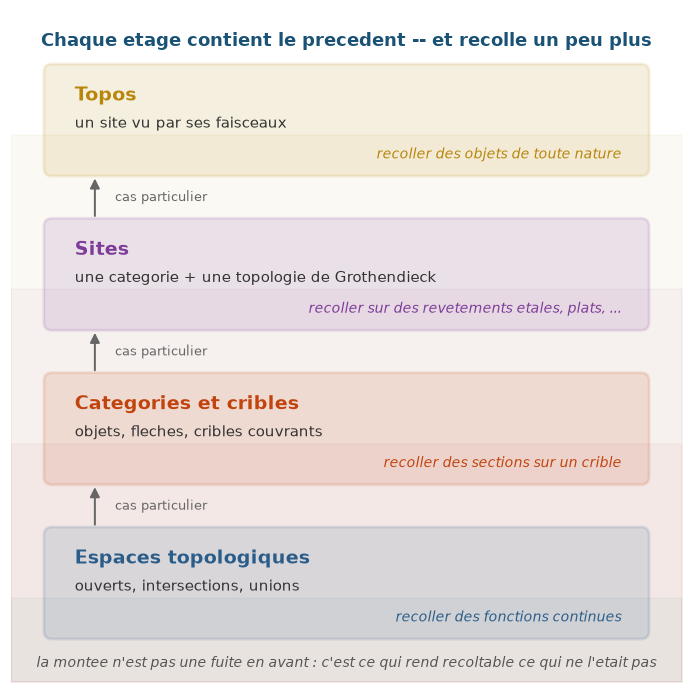

In [8]:
fig, ax = plt.subplots(figsize=(12.4, 6.4))
plan(ax)
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

etages = [
    (0.7, "Espaces topologiques", "ouverts, intersections, unions",
     "recoller des fonctions continues", C_OBJ),
    (3.0, "Categories et cribles", "objets, fleches, cribles couvrants",
     "recoller des sections sur un crible", C_SIEVE),
    (5.3, "Sites", "une categorie + une topologie de Grothendieck",
     "recoller sur des revetements etales, plats, ...", C_COVER),
    (7.6, "Topos", "un site vu par ses faisceaux",
     "recoller des objets de toute nature", C_SHEAF),
]

# La mer qui monte : une bande de fond de plus en plus haute.
mer = np.linspace(0, 10, 400)
for i, (y, *_ ) in enumerate(etages):
    h = y + 0.55
    ax.fill_between(mer, 0, h, color=etages[i][4], alpha=0.045, zorder=0)

for (y, titre, contenu, geste, couleur) in etages:
    ax.add_patch(FancyBboxPatch((0.55, y), 8.9, 1.55,
                                boxstyle="round,pad=0.06,rounding_size=0.12",
                                facecolor=couleur, alpha=0.13,
                                edgecolor=couleur, linewidth=1.9, zorder=2))
    ax.text(0.95, y + 1.14, titre, ha="left", va="center", fontsize=12.5,
            fontweight="bold", color=couleur, zorder=4)
    ax.text(0.95, y + 0.72, contenu, ha="left", va="center", fontsize=9.8,
            color="#333333", zorder=4)
    ax.text(9.10, y + 0.26, geste, ha="right", va="center", fontsize=9.0,
            style="italic", color=couleur, zorder=4)

# Les fleches « contient comme cas particulier », montees une a une
for i in range(len(etages) - 1):
    y0 = etages[i][0] + 1.55
    y1 = etages[i + 1][0]
    ax.add_patch(FancyArrowPatch((1.25, y0 + 0.05), (1.25, y1 - 0.05),
                                 arrowstyle="-|>", mutation_scale=13,
                                 color="#666666", linewidth=1.3, zorder=1))
    ax.text(1.55, (y0 + y1) / 2, "cas particulier", ha="left", va="center",
            fontsize=8.8, color="#666666", zorder=5)

ax.text(5.0, 9.55, "Chaque etage contient le precedent -- et recolle un peu plus",
        ha="center", va="center", fontsize=12.0, fontweight="bold",
        color="#1a5276")
ax.text(5.0, 0.28, "la montee n'est pas une fuite en avant : c'est ce qui rend "
                   "recoltable ce qui ne l'etait pas",
        ha="center", va="center", fontsize=9.4, style="italic", color="#555555")

plt.tight_layout()
plt.show()

### Lecture de la figure 7

Les quatre etages ne sont pas quatre theories differentes : c'est **la meme** construction, repetee a chaque fois avec un ingredient de plus.

| Etage | Ce qui sert de morceaux | Ce qui sert de recouvrement |
|---|---|---|
| Espaces topologiques | les ouverts | une union d'ouverts qui egale le tout |
| Categories et cribles | les objets de la categorie | un crible ferme par precomposition |
| Sites | idem, plus un choix de cribles couvrants | une famille couvrante quelconque |
| Topos | les faisceaux sur le site | idem, mais l'objet d'etude devient le faisceau |

**Le premier etage est le seul que l'on voit.** Les trois suivants remplacent tour a tour « ouvert » par « fleche », puis « union » par « crible », puis « espace » par « categorie ». A chaque remplacement, un theoreme de recollement reste au meme endroit -- mais il s'applique desormais a des objets qui n'ont aucun sens geometrique naif.

**Le mot de la fin.** Ce carnet a dessine six figures. Aucune n'est une preuve : ce sont des **cartes**. La carte ne remplace pas le territoire -- `Lean-15c` compile les enonces, `Lean-15` les catalogue, `Lean-15b` les met en exercice. Ce que la carte apporte est different : elle permet de savoir ou l'on est avant d'ouvrir un fichier.

## 8. Exercices

Les trois exercices reprennent une figure chacun, mais cette fois avec des donnees a manipuler. Ils sont ecrits en Python pur : aucune installation supplementaire, aucun acces reseau.

Les cellules d'exercice contiennent un squelette et un `print` d'attente : le carnet s'execute de bout en bout sans modification. Les solutions sont donnees a la suite, en bas de section.

### Exercice 1 : fermer un crible

On represente une petite categorie par son dictionnaire de fleches -- chaque fleche est un couple `(source, but)` d'etiquettes d'objets. Un crible sur `X` est donne comme un ensemble de couples.

Completez `fermer_crible` pour qu'elle retourne la **fermeture par precomposition** : si `(Y, X)` est dans le crible, alors `(Z, X)` doit y entrer pour toute fleche `(Z, Y)` de la categorie.

La fonction doit aussi signaler les fleches **ajoutees** par la fermeture -- c'est la difference entre le crible donne et le crible obtenu.

In [9]:
# Exercice 1 : fermeture par precomposition d'un crible
#
# La categorie : quatre objets A, B, C, D et les fleches ci-dessous.
# On lit "fleche (Z, Y)" comme "Z -> Y".
CATEGORIE = {
    ("B", "A"),   # B -> A
    ("C", "B"),   # C -> B
    ("D", "C"),   # D -> C
    ("D", "A"),   # D -> A, une fleche directe qui existe deja
}

# Crible donne sur A : on a retenu B -> A et C -> B (donc C -> B -> A).
CRIBLE_DONNE = {("B", "A")}


def fermer_crible(categorie, crible):
    """Retourne (crible_ferme, ajoutees).

    crible_ferme : l'ensemble des fleches du crible, ferme par precomposition
    ajoutees     : la liste triee des fleches presentes dans crible_ferme
                   mais absentes du crible d'entree
    """
    # TODO etudiant : partir de `set(crible)`, puis repeter l'operation
    #                "si (q, X) est dans le crible et (z, q) est une fleche
    #                 de la categorie, alors (z, X) entre dans le crible"
    #                jusqu'a stabilisation. Retourner aussi les ajouts.
    return None, None  # TODO etudiant


crible_ferme, ajoutees = fermer_crible(CATEGORIE, CRIBLE_DONNE)
print("Exercice 1 a completer")
if crible_ferme is not None:
    print("crible ferme  :", sorted(crible_ferme))
    print("ajoutees      :", ajoutees)
    print("attendu       : 3 fleches vers A : (B,A), (C,A), (D,A) -- les deux "
          "dernieres sont ajoutees par la fermeture")

Exercice 1 a completer


### Exercice 2 : tester la compatibilite d'une famille de sections

On se place dans le faisceau des fonctions continues sur $U = [0, 3]$, avec le recouvrement de la figure 4 : $U_1 = [0, 1{,}3]$, $U_2 = [1{,}0, 2{,}2]$, $U_3 = [1{,}9, 3{,}0]$.

Chaque section locale est donnee comme un tableau `(xs, ys)` echantillonne sur son ouvert. Completez `famille_compatible` pour qu'elle verifie la **condition de compatibilite** : sur chaque intersection non vide, les deux sections doivent prendre les memes valeurs, a une tolerance pres.

Indice : deux sections sont echantillonnees sur des grilles differentes. Il faut donc **interpoler** l'une sur les abscisses de l'autre avant de comparer -- comparer terme a terme deux tableaux de tailles differentes n'a pas de sens.

Un mot sur la tolerance, qui est le vrai sujet de cet exercice. Deux echantillonnages differents de la **meme** fonction continue ne coincident pas exactement : l'interpolation lineaire entre deux points d'une grille laisse un residu. Sur les donnees ci-dessous, ce residu vaut environ $10^{-6}$. Le seuil de compatibilite doit donc etre choisi **au-dessus** de l'erreur d'echantillonnage et **bien en dessous** du decalage qu'on veut detecter ($0{,}55$) -- c'est le meme arbitrage que dans tout test numerique de faisceau.

In [10]:
# Exercice 2 : la famille est-elle compatible sur les intersections ?
U1b, U2b, U3b = (0.0, 1.3), (1.0, 2.2), (1.9, 3.0)


def echantillonne(u, decalage=0.0, n=160):
    """Section locale : la meme fonction, decalee eventuellement."""
    xs = np.linspace(u[0], u[1], n)
    return xs, 1.0 + 0.6 * np.sin(xs) + decalage


# Deux familles a tester : la premiere compatible, la seconde non.
FAMILLE_OK = [echantillonne(U1b), echantillonne(U2b), echantillonne(U3b)]
FAMILLE_KO = [echantillonne(U1b), echantillonne(U2b, decalage=0.55),
              echantillonne(U3b)]


def famille_compatible(sections, ouverts, tolerance=1e-3):
    """Retourne (compatible: bool, pire_ecart: float).

    Pour chaque paire d'ouverts qui s'intersectent, comparer les deux sections
    sur l'intersection (apres interpolation sur une grille commune).

    La tolerance n'est pas cosmetique : deux echantillonnages differents d'une
    meme fonction continue ne se superposent pas exactement, l'interpolation
    lineaire laisse un residu de l'ordre de 1e-6 ici. Le seuil doit donc etre
    au-dessus de cette erreur d'echantillonnage, et bien en dessous du decalage
    qu'on cherche a detecter (0.55).
    """
    # TODO etudiant : boucler sur les paires (i, j), calculer l'intersection
    #                [max(x0), min(x1)], echantillonner une grille dedans,
    #                interpoler les DEUX sections dessus avec np.interp,
    #                et suivre le maximum de |s_i - s_j|.
    return None, None  # TODO etudiant


for nom, famille in (("FAMILLE_OK", FAMILLE_OK), ("FAMILLE_KO", FAMILLE_KO)):
    ok, ecart = famille_compatible(famille, [U1b, U2b, U3b])
    print("Exercice 2 a completer")
    if ok is not None:
        print("%s : compatible=%-5s  pire ecart=%.4f" % (nom, ok, ecart))
print("attendu       : FAMILLE_OK compatible (ecart ~0), FAMILLE_KO non "
      "(ecart 0.55)")

Exercice 2 a completer
Exercice 2 a completer
attendu       : FAMILLE_OK compatible (ecart ~0), FAMILLE_KO non (ecart 0.55)


### Exercice 3 : le critere de recouvrement du site de Zariski

Reprenons le site de Zariski de la figure 6, en passant des $U_p = D(p)$ aux ouverts de base **generaux** $D(f)$, pour $f$ un entier non nul quelconque :

$$D(f) = \{\,\mathfrak{q} \text{ premier} : f \notin \mathfrak{q}\,\}, \qquad\text{i.e.}\qquad D(f) = \operatorname{Spec} \mathbb{Z} \setminus \{(q) : q \text{ premier divisant } f\}.$$

$D(f)$ retire donc les diviseurs premiers de $f$ -- un seul pour $f = p$, plusieurs pour $f = 6$, aucun pour $f = 1$ (car $D(1)$ est tout l'espace). Sur une famille $f_1, \ldots, f_n$, ce qui survit est l'intersection des retenues :

$$\operatorname{Spec} \mathbb{Z} \setminus \bigl(D(f_1) \cup \cdots \cup D(f_n)\bigr) = \{(q) : q \text{ divise chacun des } f_i\} = \{(q) : q \mid \gcd(f_1, \ldots, f_n)\}.$$

Completez `points_decouverts` pour qu'elle retourne les points **non couverts** par une famille donnee. Le critere de recouvrement en tombe tout seul :

$$D(f_1) \cup \cdots \cup D(f_n) = \operatorname{Spec} \mathbb{Z} \quad\Longleftrightarrow\quad \gcd(f_1, \ldots, f_n) = 1 \quad\Longleftrightarrow\quad (f_1, \ldots, f_n) = \mathbb{Z}.$$

La derniere forme est celle qui compte : les $f_i$ engendrent l'ideal unite. C'est **exactement** la condition de recouvrement d'un site de Zariski sur un anneau quelconque -- $\mathbb{Z}$ n'y joue aucun role particulier.

In [11]:
# Exercice 3 : quels points survivent a une famille d'ouverts D(f) ?
def points_decouverts(famille, premiers_connus):
    """Retourne la liste triee des points de Spec Z non couverts par les D(f).

    L'ouvert D(f) contient (q) si et seulement si q ne divise pas f. Un point
    (q) survit donc a la famille entiere si et seulement si q divise TOUS les
    f de la famille -- c'est-a-dire si q divise leur pgcd.
    """
    # TODO etudiant : calculer g = pgcd de famille, puis retourner les premiers
    #                de premiers_connus qui divisent g, sous forme triee.
    return None  # TODO etudiant


PREMIERS = [2, 3, 5, 7, 11, 13]
familles = ([2], [2, 3], [6, 10], [30, 42], PREMIERS)
for famille in familles:
    restants = points_decouverts(famille, PREMIERS)
    print("Exercice 3 a completer")
    if restants is not None:
        print("D%-18s -> restent %d point(s) : %s"
              % (famille, len(restants), restants))

print("Question : quelle est la plus petite famille qui couvre Spec Z entier ?")
print("Reponse (a completer) : ...")

Exercice 3 a completer
Exercice 3 a completer
Exercice 3 a completer
Exercice 3 a completer
Exercice 3 a completer
Question : quelle est la plus petite famille qui couvre Spec Z entier ?
Reponse (a completer) : ...


### Solution de l'exercice 1 -- fermer un crible

La fermeture se calcule par un point fixe : on repete l'operation tant qu'elle ajoute quelque chose. Partir d'un crible donne et le **saturer** est exactement ce que fait la definition -- l'enonce par « si $f \in S$ alors $f \circ h \in S$ » est une regle de saturation, pas une enumeration.

Sur la categorie de l'exercice, le crible engendre par $\{B \to A\}$ contient **trois** fleches, toutes arrivant sur $A$ :

- $B \to A$, celle du crible de depart ;
- $C \to A$, obtenue en composant $C \to B$ avec $B \to A$ ;
- $D \to A$, obtenue en composant $D \to C$ avec $C \to A$.

Les deux dernieres sont **ajoutees** par la fermeture : elles ne figuraient pas dans le crible donne. Noter que $D \to A$ existe aussi comme fleche directe de la categorie -- la fermeture la retrouve par composition, et le resultat est le meme ensemble. C'est exactement la propriete de saturation qui fait qu'un crible est determine par ses elements maximaux.

In [12]:
def fermer_crible_solution(categorie, crible):
    """Fermeture par precomposition, par point fixe."""
    ferme = set(crible)
    while True:
        ajouts = set()
        for (q, cible) in ferme:
            # toute fleche (z, q) se compose avec (q, cible)
            for (source, but) in categorie:
                if but == q and source != cible:
                    ajouts.add((source, cible))
        nouveaux = ajouts - ferme
        if not nouveaux:
            break
        ferme |= nouveaux
    return ferme, sorted(ferme - set(crible))


ferme, ajoutees = fermer_crible_solution(CATEGORIE, CRIBLE_DONNE)
print("crible ferme :", sorted(ferme))
print("ajoutees     :", ajoutees)
print("nombre final :", len(ferme), "fleches vers A")
assert ferme == {("B", "A"), ("C", "A"), ("D", "A")}, ferme
assert ajoutees == [("C", "A"), ("D", "A")], ajoutees
print("OK : la fermeture ajoute exactement les deux compositions")

crible ferme : [('B', 'A'), ('C', 'A'), ('D', 'A')]
ajoutees     : [('C', 'A'), ('D', 'A')]
nombre final : 3 fleches vers A
OK : la fermeture ajoute exactement les deux compositions


### Solution de l'exercice 2 -- compatibilite d'une famille

Le piege de cet exercice n'est pas la condition de faisceau, c'est l'**echantillonnage**. Deux sections locales sont echantillonnees sur des grilles differentes : comparer leurs tableaux terme a terme comparerait des valeurs prises en des points differents, ce qui n'a aucun sens. Il faut interpoler.

Une fois l'interpolation faite, la condition est immediate : sur chaque intersection, l'ecart maximal entre les deux sections doit rester sous la tolerance.

Le resultat fait apparaitre la difference entre les deux familles de la figure 4 : la premiere donne un ecart de l'ordre de $10^{-6}$, la seconde un ecart de $0{,}55$ -- exactement le decalage introduit.

**Les deux ordres de grandeur sont le vrai enseignement.** L'ecart de la famille compatible n'est pas nul, et il ne peut pas l'etre : deux echantillonnages distincts d'une meme fonction continue ne se superposent qu'a l'erreur d'interpolation pres. Un test de compatibilite qui exigerait l'egalite exacte declarerait incompatible une famille parfaitement recollable. La tolerance est donc une piece du raisonnement, pas un confort : elle se place entre le bruit d'echantillonnage ($\sim 10^{-6}$) et le defaut cherche ($0{,}55$) -- cinq ordres de grandeur de marge.

In [13]:
def famille_compatible_solution(sections, ouverts, tolerance=1e-3):
    """Compatibilite deux a deux sur les intersections, apres interpolation."""
    pire = 0.0
    for i in range(len(ouverts)):
        for j in range(i + 1, len(ouverts)):
            x0 = max(ouverts[i][0], ouverts[j][0])
            x1 = min(ouverts[i][1], ouverts[j][1])
            if x1 <= x0:
                continue                      # intersection vide : rien a tester
            grille = np.linspace(x0, x1, 200)
            si = np.interp(grille, sections[i][0], sections[i][1])
            sj = np.interp(grille, sections[j][0], sections[j][1])
            pire = max(pire, float(np.max(np.abs(si - sj))))
    return pire <= tolerance, pire


for nom, famille in (("FAMILLE_OK", FAMILLE_OK), ("FAMILLE_KO", FAMILLE_KO)):
    ok, ecart = famille_compatible_solution(famille, [U1b, U2b, U3b])
    print("%s : compatible=%-5s  pire ecart=%.4f" % (nom, ok, ecart))

ok1, e1 = famille_compatible_solution(FAMILLE_OK, [U1b, U2b, U3b])
ok2, e2 = famille_compatible_solution(FAMILLE_KO, [U1b, U2b, U3b])
assert ok1 and e1 < 1e-4, (ok1, e1)          # residu d'interpolation, pas 0
assert (not ok2) and abs(e2 - 0.55) < 1e-4, (ok2, e2)
print("OK : compatible (residu %.1e) / incompatible (ecart 0.55)" % e1)

FAMILLE_OK : compatible=True   pire ecart=0.0000
FAMILLE_KO : compatible=False  pire ecart=0.5500
OK : compatible (residu 4.2e-06) / incompatible (ecart 0.55)


### Solution de l'exercice 3 -- le critere par le pgcd

La fonction tient en trois lignes : on calcule le pgcd de la famille, puis on garde les premiers connus qui le divisent. Toute la geometrie est dans le pgcd.

| Famille | Points non couverts |
|---|---|
| $D(2)$ | $(2)$ |
| $D(2), D(3)$ | aucun |
| $D(6), D(10)$ | $(2)$, car $\gcd(6,10) = 2$ |
| $D(30), D(42)$ | $(2), (3)$, car $\gcd(30,42) = 6$ |
| tous les $D(p)$, $p$ premier | aucun, car leur pgcd vaut $1$ |

Deux consequences meritent d'etre nommees.

**La plus petite famille couvrante a deux elements.** $D(2) \cup D(3) = \operatorname{Spec} \mathbb{Z}$ : aucun ideal premier ne contient a la fois $2$ et $3$, donc aucun point n'echappe aux deux ouverts. Une infinite de points, deux ouverts -- c'est la quasi-compacite de $\operatorname{Spec} \mathbb{Z}$ rendue visible, et le meme phenomene que le tableau de la figure 6.

**Le critere se transporte tel quel.** $D(f_1) \cup \cdots \cup D(f_n)$ couvre si et seulement si $\gcd = 1$, c'est-a-dire si les $f_i$ **engendrent l'ideal unite**. Ecrit ainsi, l'enonce ne mentionne plus $\mathbb{Z}$ : sur $\operatorname{Spec} A$ pour un anneau $A$ quelconque, la famille des $D(f_i)$ couvre si et seulement si $(f_1, \ldots, f_n) = A$. Le cas de $\mathbb{Z}$ etait un cas particulier d'une condition qui n'a rien d'arithmetique.

**Ce que l'exercice fait mesurer** : « recouvrir » n'est pas une question de cardinalite ni de reunion d'ensembles -- c'est une condition **algebrique** sur les generateurs (engendrer l'ideal unite), ou sur les fleches (former un crible couvrant) quand il n'y a plus d'ideal unite a invoquer.

In [14]:
from math import gcd


def points_decouverts_solution(famille, premiers_connus):
    """Points de Spec Z non couverts par la famille d'ouverts D(f)."""
    g = 0
    for f in famille:
        g = gcd(g, f)
    return sorted(q for q in premiers_connus if g % q == 0)


attendus = (([2], [2]), ([2, 3], []), ([6, 10], [2]),
            ([30, 42], [2, 3]), (tuple(PREMIERS), []))
for famille, attendu in attendus:
    famille = list(famille)
    restants = points_decouverts_solution(famille, PREMIERS)
    print("D%-18s -> restent %s" % (famille, restants))
    assert restants == attendu, (famille, restants, attendu)

print()
print("Deux ouverts suffisent : D(2) union D(3) couvre Spec Z entier.")
print("Critere general : la famille couvre si et seulement si le pgcd vaut 1,")
print("c'est-a-dire si les f engendrent l'ideal unite (f_1, ..., f_n) = Z.")
print("Sur un anneau A quelconque, le meme critere s'ecrit (f_1, ..., f_n) = A.")

D[2]                -> restent [2]
D[2, 3]             -> restent []
D[6, 10]            -> restent [2]
D[30, 42]           -> restent [2, 3]
D[2, 3, 5, 7, 11, 13] -> restent []

Deux ouverts suffisent : D(2) union D(3) couvre Spec Z entier.
Critere general : la famille couvre si et seulement si le pgcd vaut 1,
c'est-a-dire si les f engendrent l'ideal unite (f_1, ..., f_n) = Z.
Sur un anneau A quelconque, le meme critere s'ecrit (f_1, ..., f_n) = A.
